In [1]:
#!/usr/bin/env python
################################################
# New style 
# ###############################################
import sys
import os

rootdir_ = '../'
if ( rootdir_ not in sys.path ):
    sys.path.append(rootdir_)
    print( f" a path to {rootdir_} added in {__name__} ")


from Utils import GridUtils as GrU
from Utils import utils as uti
from Utils import MyConstants as Co
from Utils import numerical_utils as nuti

#from PyRegridding.Utils import MakePressures as MkP
#from Drivers import RegridField as RgF
import RegridField as RgF
import update_config as uc
#local utils.py
import utils as U 



# The usual
from datetime import date
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

# Extra for analysis and 'loggy' levels
from scipy.ndimage import uniform_filter
from scipy.ndimage import gaussian_filter
import matplotlib.colors as mcolors


# Some other useful packages 
import copy
import time
import cftime
import yaml
import numbers
import importlib
from pathlib import Path

# Constants
grav=Co.grav()
cp=Co.cpair()
Rdair=Co.Rdair()
R_earth=Co.Rearth()

importlib.reload(U)


 a path to ../ added in __main__ 
 Utils.MyConstants in /glade/work/juliob/HiRes_ana_dev/Drivers/Utils 
Using Flexible parallel/serial VertRegrid 
 Utils.MyConstants in /glade/work/juliob/HiRes_ana_dev/Drivers/Utils 
 a path to /glade/work/juliob added in Utils.numerical_utils 


<module 'utils' from '/glade/work/juliob/HiRes_ana_dev/Drivers/Analysis/utils.py'>

In [ ]:

f1='/glade/work/juliob/HiRes_ana_dev/Drivers/mpasa3p75_topo_ON_UHR_SEUS.nc'
f2='/glade/work/juliob/HiRes_ana_dev/Drivers/ne120pg3_topo_ON_UHR_SEUS.nc'
Topo1=xr.open_dataset( f1 )
Topo2=xr.open_dataset( f2 )



h1=Topo1.PHIS.values/grav
h2=Topo2.PHIS.values/grav

lat=Topo1.lat.values
lon=Topo1.lon.values


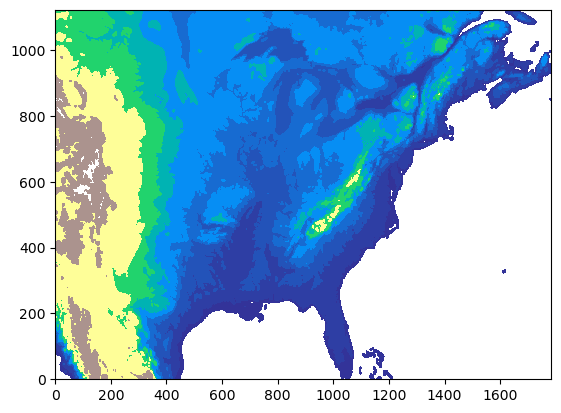

In [15]:
plt.contourf(h1,cmap='terrain',levels=[0,1,10,100,200,300,500,700,1000,2000,3000])

In [ ]:
"""
f='/glade/campaign/cgd/amp/juliob/mpasa3p75km/cam77_dyamond1_prod1/2016-08-01-32400/w_dyamond.nc'
X1=xr.open_dataset( f )

f='/glade/campaign/cgd/amp/juliob/mpasa3p75km/cam77_dyamond1_prod1/2016-08-01-32400/w_mpas_dyamond.nc'
X2=xr.open_dataset( f )
"""

f='/glade/campaign/cgd/amp/juliob/mpasa3p75km/cam77_dyamond1_prod1/2016-08-02-43200/DynVars_dyamond_fv1x1.2016-08-02-43200.nc'
X1=xr.open_dataset( f )




In [ ]:
theta = X1.theta_mpas.values
zg=X1.zgrid.values

In [ ]:
zg.shape
t,z,y,x = 0,5,90,144
plt.plot( theta[t,:,y,x] ,zg[1:,y,x] )

In [ ]:

w1=X1.w.values
w2=X2.w_mpas.values

lev1=X1.ilev.values
lev2=X2.ilev.values


In [ ]:
plt.plot(  w1[0,:,2_000_000]  , lev1)
plt.plot(  w2[0,:,2_000_000]  ,lev2 )


In [ ]:
theta2=X2.theta.values
lev2=X2.lev.values


theta=X.theta_mpas.values
lev=X.lev.values
print(lev)
print(lev2)



In [ ]:
X.theta_mpas.dims

In [ ]:
plt.plot(  theta[0,:,2_000_000]  )

In [ ]:

P1 = xr.open_dataset( '/glade/campaign/cgd/amp/juliob/mpasa3p75km/TimeInvariant/PHIS_dyamond_UHR_SAndesAP.nc' )
phis1=P1.PHIS.values
lon1=P1.lon.values
lat1=P1.lat.values


In [ ]:

P2 = xr.open_dataset( '/glade/campaign/cgd/amp/juliob/mpasa3p75km/TimeInvariant/PHIS_dyamond_UHR_SO-Indian.nc' )
phis2=P2.PHIS.values
lon2=P2.lon.values
lat2=P2.lat.values


In [ ]:
print( phis2.shape )

In [ ]:
plt.contourf( lon1, lat1, phis1 , levels=51 )

In [ ]:
plt.contourf( lon2, lat2, phis2 , levels=51 )

In [ ]:
pi=np.acos(-1.)

degrad = pi/180.

print(pi)

dx=(lon2[1]-lon2[0]) * degrad * R_earth * np.cos( np.mean(lat2) * degrad ) 
dy=(lat2[1]-lat2[0]) * degrad * R_earth 

print( dx,dy )





In [ ]:
%%time
year,month,day,hour=2004,7,15,0
if ( day == '*'):
    date_tag = f"{year:04}-{month:02}-*"
elif ( hour == '*'):
    date_tag = f"{year:04}-{month:02}-{day:02}-*"
else:   
    seconds=hour*3_600
    date_tag = f"{year:04}-{month:02}-{day:02}-{seconds:05}"

print(date_tag)

In [ ]:
f0=f'/glade/derecho/scratch/juliob/archive//c153_topfix_ne240pg3_FMTHIST_xic_x02/atm/fv1x1/c153_topfix_ne240pg3_FMTHIST_xic_x02.cam.h1i.{date_tag}.nc' 
f1=f'/glade/derecho/scratch/juliob/archive//c153_topfix_ne240pg3_FMTHIST_xic_x02/atm/fv1x1_noscl/c153_topfix_ne240pg3_FMTHIST_xic_x02.cam.h1i.{date_tag}.nc' 


#ncdata='/glade/derecho/scratch/juliob/archive/test_fgf/atm/regridded/test_fgf.cam.h2i.1985-07-15-00000.nc'
#f='/glade/derecho/scratch/juliob/archive/GW_UnitTest/xy-frontal-04/xy-frontal-04.h.1985-07-15-00000.nc'
 

X0=xr.open_mfdataset( f0 ,data_vars='different', coords='different' , compat='no_conflicts' )
X1=xr.open_mfdataset( f1 ,data_vars='different', coords='different' , compat='no_conflicts' )


In [ ]:


lon=X0.lon.values
lat=X0.lat.values

Lon,Lat=np.meshgrid(lon,lat)


ftopo='/glade/work/juliob/Topo/NCARTopoJTB/cases/fv1x1_Sco100_GrnlAnt/output/fv1x1_gmted2010_modis_bedmachine_nc3000_Laplace0100_noleak_greenlndantarcsgh30fac2.50_20251009.nc'
Topo=xr.open_dataset( ftopo )

hs = Topo.PHIS.values/grav
sgh = Topo.SGH.values
sgh30 = Topo.SGH30.values

In [ ]:
plev=X0.lev.values
zlev=-7_000.*np.log( plev/1_000.)
levn=np.arange( len(plev) )

In [ ]:
mask= sgh < 10

In [ ]:

upwp0 = X0.upwp.values
vpwp0 = X0.vpwp.values
epwp0 = np.sqrt( upwp0**2 + vpwp0**2 )

upwp1 = X1.upwp.values
vpwp1 = X1.vpwp.values
epwp1 = np.sqrt( upwp1**2 + vpwp1**2 )


In [ ]:
plt.contourf( upwp0[0,20,:,:] )
plt.xlim( 232,242)
plt.ylim( 20,30)


In [ ]:
z,y,x=20,27,238
#plt.plot( upwp0[0,:,y,x], levn )
#plt.plot( upwp1[0,:,y,x], levn )
plt.plot( upwp0[0,z,:,:].flatten() )
plt.plot( upwp1[0,z,:,:].flatten()-upwp0[0,z,:,:].flatten() )


In [ ]:
X0

In [ ]:
from Utils import MakePressures as MkP
importlib.reload(MkP)

pmid,pint,delp=MkP.Pressure(X=X0,Gridkey='tzyx')


In [ ]:
"""
am=X0.hyam.values
bm=X0.hybm.values
ai=X0.hyai.values
bi=X0.hybi.values
ps=X0.PS.values
pmid2,pint2,delp2 = MkP.Pressure ( am=am, bm=bm, ai=ai, bi=bi, ps=ps, Gridkey='tzyx' )
"""

In [ ]:
te=X0.T.values

rho3=pmid/(Rdair*te)

In [ ]:
z=28
#plt.plot( rho3[0,z,:,:].flatten() - 0*X0.RhoProxy.values[z] )
plt.plot( rho3[0,z,:,:].flatten() )
#plt.plot( rho3[0,z,:,:].flatten() / X0.RhoProxy.values[z] )
plt.plot( np.full( 50_000, X0.RhoProxy.values[z] ))


In [ ]:
#plev=X.lev.values
plev=100_000. * (X.hyam.values+X.hybm.values)
zlev=-7_000. * np.log( plev / 100_000. )

In [ ]:
flev=0.01*np.asarray( [0.0001,0.0002,0.0005,  0.001,0.0015,0.002,0.003,0.004,0.005,0.006,0.008,    0.01,0.015,0.02,0.03,0.04,0.05,0.06,  0.1,0.15,0.2,0.3,0.4,0.5,0.6,   1.0,1.5,2.0,3,4,5,6 ] )
print(flev)
cmap_name='gist_ncar'
wavlev=26
case="UnitTest vs. ne240"
title=f'{case}: {year:04}-{month:02}, Z={zlev[wavlev]/1000.:.0f} km '     #        camsnap-yaaaa.h.2004-06-15-21600.nc'

print( zlev[wavlev] )
cmap = plt.cm.gist_ncar #.bwr  #gist_ncar  # Or any other colormap
norm = mcolors.BoundaryNorm(boundaries=flev, ncolors=cmap.N, clip=False)
fig,axs=plt.subplots( 1, 3, figsize=(25,6) )
p=0
ax=axs[p]
c=ax.contourf( lon,lat, np.average(tau_fr,axis=0)[wavlev,:,:]*mask , levels=flev, cmap=cmap, norm=norm, extend='both'  ) #levels=51)
to = ax.contour( lon,lat,hs, levels=[1,100] ,colors='black')
ax.set_xlabel( "Longitude" )
ax.set_ylabel( "Latitude" )
ax.set_title( "Frontal GW")
plt.colorbar(c)

p=1
ax=axs[p]
c=ax.contourf( lon,lat, np.average(tau_mm,axis=0)[wavlev,:,:] *mask, levels=flev, cmap=cmap, norm=norm, extend='both' ) #levels=51)
to = ax.contour( lon,lat,hs, levels=[1,100] ,colors='black')
ax.set_xlabel( "Longitude" )
ax.set_ylabel( "Latitude" )
ax.set_title( "Moving mtn GW")
plt.colorbar(c)


p=2
ax=axs[p]
c=ax.contourf( lon,lat, np.average( epwp ,axis=0)[wavlev,:,:] , levels=flev, cmap=cmap, norm=norm, extend='both' ) #levels=51)
to = ax.contour( lon,lat,hs, levels=[1,100] ,colors='black')
ax.set_xlabel( "Longitude" )
ax.set_ylabel( "Latitude" )
ax.set_title( "ne240 resolved tau")
plt.colorbar(c)
plt.suptitle( title , fontsize=24)

#plt.contourf( np.average(-tauw_fr,axis=0)[20,:,:] )

In [ ]:
y,x=40,50
#y,x=60,70

fig,axs=plt.subplots(1,2 , figsize=(20,6) )

p=0
ax=axs[p]
ax.plot( np.average(tauw_fr,axis=0)[1:,y,x], zlev )
ax.plot( np.average(taue_fr,axis=0)[1:,y,x], zlev )
ax.plot( np.average(upwp,axis=0)[0:,y,x], zlev )
ax.set_ylim(10000,85000)
p=1
ax=axs[p]
ax.plot( np.average(tauw_mm,axis=0)[1:,y,x], zlev )
ax.plot( np.average(taue_mm,axis=0)[1:,y,x], zlev )
ax.plot( np.average(upwp,axis=0)[0:,y,x], zlev )
ax.set_ylim(10000,85000)


In [ ]:
%%time

fgf =X.FRONTGF.values
#th = X.TH.values
#fgf_nc =Xnc.FRONTGF.values

pmid=X.PMID.values

In [ ]:
wavlev=40
srclev=70
t=0

flev=10.*np.asarray( [0.0001,0.0002,0.0005,  0.001,0.0015,0.002,0.003,0.004,0.005,0.006,0.008,    0.01,0.015,0.02,0.03,0.04,0.05,0.06,  0.1,0.15,0.2,0.3,0.4,0.5,0.6,   1.0,1.5,2.0,3,4,5,6 ] )
print(flev)
cmap_name='plasma' #'gist_ncar'


cmap = plt.cm.Blues #.bwr  #gist_ncar  # Or any other colormap
norm = mcolors.BoundaryNorm(boundaries=flev, ncolors=cmap.N, clip=False)

fig,axs=plt.subplots( 1, 3, figsize=(30,6) )

ax=axs[0]
#c=ax.contourf( lon,lat, grd2se[15,srclev,:,:] , levels=np.linspace(0.,0.01,num=51), cmap=cmap) #levels=51)
c=ax.contourf( lon,lat, fgf[t,srclev,:,:] , levels=1.e-13*np.linspace(-1.,1.,num=51), cmap=cmap) #levels=51)
to = ax.contour( lon,lat,hs, levels=[1,100] ,colors='black')
ax.set_title(" Unit test FRONTGF ")
plt.colorbar(c)

ax=axs[1]
c=ax.contourf( lon,lat, fgf_nc[t,srclev,:,:] , levels=1.e-13*np.linspace(-1.,1.,num=51), cmap=cmap) #levels=51)
to = ax.contour( lon,lat,hs, levels=[1,100] ,colors='black')
ax.set_title(" ncdata FRONTGF ")
plt.colorbar(c)

ax=axs[2]
c=ax.contourf( lon,lat, (fgf_nc-fgf)[t,srclev,:,:] , levels=1.e-13*np.linspace(-1.,1.,num=51), cmap=cmap) #levels=51)
to = ax.contour( lon,lat,hs, levels=[1,100] ,colors='black')
plt.colorbar(c)

#print( X.lev[srclev].values)


In [ ]:
taunet    = np.sqrt( X.TAUE.values**2 + X.TAUW.values**2  + X.TAUN.values**2 + X.TAUS.values**2 )
taunet_nc = np.sqrt( Xnc.TAUE.values**2 + Xnc.TAUW.values**2  + Xnc.TAUN.values**2 + Xnc.TAUS.values**2 )

In [ ]:
wavlev=20
srclev=70
t=0

flev=.1*np.asarray( [0.0001,0.0002,0.0005,  0.001,0.0015,0.002,0.003,0.004,0.005,0.006,0.008,    0.01,0.015,0.02,0.03,0.04,0.05,0.06,  0.1,0.15,0.2,0.3,0.4,0.5,0.6,   1.0,1.5,2.0,3,4,5,6 ] )
print(flev)
cmap_name='plasma' #'gist_ncar'


cmap = plt.cm.Blues #.bwr  #gist_ncar  # Or any other colormap
norm = mcolors.BoundaryNorm(boundaries=flev, ncolors=cmap.N, clip=False)

fig,axs=plt.subplots( 1, 3, figsize=(30,6) )

ax=axs[0]
#c=ax.contourf( lon,lat, grd2se[15,srclev,:,:] , levels=np.linspace(0.,0.01,num=51), cmap=cmap) #levels=51)
c=ax.contourf( lon,lat, taunet[t,wavlev,:,:] , levels=flev, cmap=cmap, norm=norm) #levels=51)
to = ax.contour( lon,lat,hs, levels=[1,100] ,colors='black')
ax.set_title(" Unit test TAUE ")
plt.colorbar(c)

ax=axs[1]
c=ax.contourf( lon,lat, taunet_nc[t,wavlev,:,:] , levels=flev, cmap=cmap,norm=norm) #levels=51)
to = ax.contour( lon,lat,hs, levels=[1,100] ,colors='black')
ax.set_title(" ncdata TAUE ")
plt.colorbar(c)

ax=axs[2]
c=ax.contourf( lon,lat, (taunet_nc-taunet)[t,wavlev,:,:] , levels=51, cmap=cmap) #levels=51)
to = ax.contour( lon,lat,hs, levels=[1,100] ,colors='black')
plt.colorbar(c)

#print( X.lev[srclev].values)


In [ ]:

plt.plot( X.TAUE.values.flatten() )
plt.plot( X.TAUW.values.flatten() )


In [ ]:
plt.plot( grd2se[15,srclev,40,:] )
plt.plot( 1000.* 1000.* dth2[15,srclev,40,:] )


In [ ]:
wavlev=20
srclev=75


flev=0.1*np.asarray( [0.0001,0.0002,0.0005,  0.001,0.0015,0.002,0.003,0.004,0.005,0.006,0.008,    0.01,0.015,0.02,0.03,0.04,0.05,0.06,  0.1,0.15,0.2,0.3,0.4,0.5,0.6,   1.0,1.5,2.0,3,4,5,6 ] )
print(flev)
cmap_name='plasma' #'gist_ncar'

cmap = plt.cm.Blues #.bwr  #gist_ncar  # Or any other colormap
norm = mcolors.BoundaryNorm(boundaries=flev, ncolors=cmap.N, clip=False)

fig,axs=plt.subplots( 1, 4, figsize=(40,6) )
ax=axs[0]
c=ax.contourf( lon,lat, np.mean( epwp[:,wavlev,:,:],axis=0) , levels=flev, cmap=cmap, norm=norm ) #levels=51)
to = ax.contour( lon,lat,hs, levels=[1,100] ,colors='black')
plt.colorbar(c)
ax=axs[1]
c=ax.contourf( lon,lat, np.mean( zeta2[:,srclev,:,:], axis=0) , levels=np.linspace(0.,1e-8,num=51), cmap=cmap) #levels=51)
to = ax.contour( lon,lat,hs, levels=[1,100] ,colors='black')
plt.colorbar(c)
ax=axs[2]
c=ax.contourf( lon,lat, 1000.*np.mean( grd2se[:,srclev,:,:], axis=0) , levels=np.linspace(0.,0.001,num=51), cmap=cmap) #levels=51)
#c=ax.contourf( lon,lat, np.mean( fgx[:,srclev,:,:], axis=0) , levels= 1.0e-8*np.linspace(-1.,1.,num=51), cmap=cmap) #levels=51)
to = ax.contour( lon,lat,hs, levels=[1,100] ,colors='black')
plt.colorbar(c)
print( X.lev[srclev].values)
ax=axs[3]
c=ax.contourf( lon,lat, np.mean( tp2[:,srclev,:,:], axis=0) , levels=  np.linspace(0.,0.5,num=51)  , cmap=cmap) #levels=51)
to = ax.contour( lon,lat,hs, levels=[1,100] ,colors='black')
plt.colorbar(c)
print( X.lev[srclev].values)


In [ ]:
plt.plot( tp2[15,srclev,:,:] .flatten() )
print( X.time[15] )

In [ ]:
#Pick z level ...
z=35

ayx=epwp[:,z,:,:]
print ( ayx.shape)

zlev=-7.0*np.log( X.lev.values /1000. )


print( zlev[z] )

In [ ]:



flev=[0.0001,0.0002,0.0005,  0.001,0.0015,0.002,0.003,0.004,0.005,0.006,0.008,    0.01,0.015,0.02,0.03,0.04,0.05,0.06,  0.1,0.15,0.2,0.3,0.4,0.5,0.6,   1.0,1.5,2.0,3,4,5,6 ]
print(flev)
cmap_name='plasma' #'gist_ncar'

payx=np.average( ayx, axis=0 )

cmap = plt.cm.Blues #.bwr  #gist_ncar  # Or any other colormap
norm = mcolors.BoundaryNorm(boundaries=flev, ncolors=cmap.N, clip=False)

fig,axs=plt.subplots( 1, 3, figsize=(30,6) )
ax=axs[0]
c=ax.contourf( lon,lat,np.mean( ayx, axis=0) , levels=flev, cmap=cmap, norm=norm ) #levels=51)
to = ax.contour( lon,lat,hs, levels=[1,100] ,colors='black')
plt.colorbar(c)
ax=axs[1]
c=ax.contourf( lat,zlev,np.mean( np.mean(epwp, axis=3) , axis=0) , levels=flev, cmap=cmap, norm=norm ) #levels=51)
plt.colorbar(c)

In [ ]:
#plt.contourf( ayx[:,30,:] ,levels=np.linspace(-.1,.1,num=51), cmap='bwr' )

#plt.contourf( ayx[:,30,:] ,levels=np.linspace(0,.01,num=51), cmap='bwr' )
#plt.contourf( ayx[:,40,:] ,levels=flev, cmap=cmap, norm=norm )

fig,axs = plt.subplots( 1 , 2, figsize=(15,7) )


ax=axs[0]
ax.contourf( ayx[:,40,:] ,levels=flev, cmap=cmap, norm=norm ) 
ax=axs[1]
ax.contour( zeta2[:,srclev,40,:] ,levels=21, cmap=cmap )
print(lat[40])


In [ ]:
nt,nz,ny,nx = np.shape(z3o)
Lon_zx=np.zeros( (nz,nx) )
for k in np.arange( nz ):
    Lon_zx[k,:]=lon[:]

In [ ]:
lat_zx=-42.
t,y=15,np.argmin( np.abs(lat-lat_zx ) )
print( y )
#plt.contourf( Lon_zx, z3o[t,:,y,:] , zeta2[t,:,y,:] )
#plt.contourf( Lon_zx, z3o[t,:,y,:] , grd2se[t,:,y,:] ,levels=np.linspace(0.,0.01,num=51), cmap=cmap)
#plt.ylim(0,20_000)

cmap = plt.cm.Blues #.bwr  #gist_ncar  # Or any other colormap
norm = mcolors.BoundaryNorm(boundaries=flev, ncolors=cmap.N, clip=False)

zrang=[0,20_000.]
fig,axs=plt.subplots( 1, 3, figsize=(30,6) )

ax=axs[0]
c=ax.contourf( Lon_zx, z3o[t,:,y,:] , epwp[t,:,y,:] , levels=flev, cmap=cmap, norm=norm ) #levels=51)
ax.set_ylim( zrang )
ax.plot( lon, z3e[t,nz,y,:] )
plt.colorbar( c )

ax=axs[1]
c=ax.contourf( Lon_zx, z3o[t,:,y,:] , zeta[t,:,y,:] , levels=np.linspace(-0.002,0.002,num=51), cmap='bwr' ) #levels=51)
ax.set_ylim( zrang )
plt.colorbar( c )


ax=axs[2]
c=ax.contourf( Lon_zx, z3o[t,:,y,:] , grd2se[t,:,y,:] , levels=np.linspace(0,0.01,num=51), cmap=cmap ) #levels=51)
ax.set_ylim( zrang )
plt.colorbar( c )




In [ ]:
plt.plot( np.mean( zeta2[:,srclev,:,:], axis=0).flatten() )

In [ ]:
bins=np.linspace(0.001,0.201,num=51)
h= np.histogram(ayx[:,30:50,0:100].flatten() , bins=bins)

In [ ]:
h

In [ ]:
plt.plot(h[1][0:-1],np.log(h[0]+0.1) )


In [ ]:
trunc_k, sigma=20, 2.
hs_sm = gaussian_filter(  hs , sigma=sigma,
                           truncate=((trunc_k-1)/2)/sigma, mode="nearest")

threshold=0.025 #1
#threshold=0.01 #1

#it, iy, ix = np.where( (ayx > threshold) & (hs_sm <0.1)) #(ayx > threshold)
#mask_int = ( (ayx > threshold) & (hs_sm <0.1)).astype(int)


#booleo= (ayx > threshold) & (hs_sm <0.1) & (Lat>40) & (Lat<70) # & (Lat<-35.) & (Lon<150.)
booleo= (ayx > threshold) & (hs_sm <0.1) & (Lat<-35.) #& (Lon<150.)
it, iy, ix = np.where( booleo) #(ayx > threshold)
mask_int = booleo.astype(int)


booleo_ctl= (ayx > 0.) & (hs_sm <0.1) & (Lat<-35.) #& (Lon<150.)
it_ctl, iy_ctl, ix_ctl = np.where( booleo_ctl) #(ayx > threshold)
mask_ctl_int = booleo_ctl.astype(int)


In [ ]:
nps=len(ix)
print( nps )


In [ ]:



flev=[0.0001,0.0002,0.0005,  0.001,0.0015,0.002,0.003,0.004,0.005,0.006,0.008,    0.01,0.015,0.02,0.03,0.04,0.05,0.06,  0.1,0.15,0.2,0.3,0.4,0.5,0.6,   1.0,1.5,2.0,3,4,5,6 ]
print(flev)
cmap='plasma' #'gist_ncar'

payx=np.average( ayx, axis=0 )
payx_mask=np.sum( ayx*mask_int, axis=0 )/(np.sum(mask_int, axis=0 ))

cmap = plt.cm.Blues #gist_ncar  #gist_ncar  # Or any other colormap
norm = mcolors.BoundaryNorm(boundaries=flev, ncolors=cmap.N, clip=False)

fig,axs=plt.subplots( 1, 3, figsize=(30,6) )
ax=axs[0]
c=ax.contourf( lon,lat,payx , levels=flev, cmap=cmap, norm=norm ) #levels=51)
to = ax.contour( lon,lat,hs, levels=[1,100] ,colors='black')
plt.colorbar(c)

ax=axs[1]
c=ax.contourf( lon,lat,payx_mask , levels=flev, cmap=cmap, norm=norm ) #levels=51)
to = ax.contour( lon,lat,hs, levels=[1,100] ,colors='black')
plt.colorbar(c)



In [ ]:
%%time
u=X.U.values
#te=X.T.values

In [ ]:
u_gw=u[it,:,iy,ix]
u_ctl=u[it_ctl, :, iy_ctl, ix_ctl]


z3o_gw=z3o[it,:,iy,ix] 
z3o_ctl=z3o[it_ctl,:,iy_ctl,ix_ctl] 
dse_gw=dse[it,:,iy,ix] /cp
dse_ctl=dse[it_ctl,:,iy_ctl,ix_ctl] /cp
zeta_gw=zeta[it,:,iy,ix]
zeta_ctl=zeta[it_ctl,:,iy_ctl,ix_ctl]
grd2se_gw=grd2se[it,:,iy,ix] /cp
grd2se_ctl=grd2se[it_ctl,:,iy_ctl,ix_ctl] /cp


In [ ]:
fig,axs=plt.subplots(1,3, figsize=(30,6) )
ax=axs[0]
ax.plot(np.average(zeta_gw,axis=0) , np.average(z3o_gw,axis=0))
ax.plot(np.average(zeta_ctl,axis=0) , np.average(z3o_ctl,axis=0))
ax.plot(  np.average(zeta_gw,axis=0) -  np.average(zeta_ctl,axis=0) , np.average(z3o_ctl,axis=0))
ax.set_ylim(0,20_000)
ax=axs[1]
ax.plot(np.average(u_gw,axis=0) , np.average(z3o_gw,axis=0))
ax.plot(np.average(u_ctl,axis=0) , np.average(z3o_ctl,axis=0))
ax.set_ylim(0,20_000)


In [ ]:
fig,axs=plt.subplots(1,3, figsize=(30,6) )
ax=axs[0]
ax.plot(np.average(grd2se_gw,axis=0) , np.average(z3o_gw,axis=0))
ax.plot(np.average(grd2se_ctl,axis=0) , np.average(z3o_ctl,axis=0))
ax.plot(  np.average(grd2se_gw,axis=0) -  np.average(grd2se_ctl,axis=0) , np.average(z3o_ctl,axis=0))
ax.set_ylim(0,20_000)


In [ ]:

plt.plot(np.average(dse_gw,axis=0))
plt.plot(np.average(dse_ctl,axis=0))
plt.ylim(280,340)

In [ ]:
print( X.lev.values[93-30-1])
print( X.lev.values[93-30+1])


In [ ]:



flev=np.linspace(-60,60,num=31) #21 0.0001,0.0002,0.0005,  0.001,0.0015,0.002,0.003,0.004,0.005,0.006,0.008,    0.01,0.015,0.02,0.03,0.04,0.05,0.06,  0.1,0.2,0.5,   1.0  ]
flev=np.linspace(-0.0005,0.0005,num=31) #21 0.0001,0.0002,0.0005,  0.001,0.0015,0.002,0.003,0.004,0.005,0.006,0.008,    0.01,0.015,0.02,0.03,0.04,0.05,0.06,  0.1,0.2,0.5,   1.0  ]
print(flev)
payx=np.average( uuu[:,60,:,:], axis=0 )
payx_mask=np.sum( uuu[:,60,:,:]*mask_int, axis=0 )/(np.sum(mask_int, axis=0 ))
payx=np.average( zeta[:,60,:,:], axis=0 )
payx_mask=np.sum( zeta[:,60,:,:]*mask_int, axis=0 )/(np.sum(mask_int, axis=0 ))


cmap = plt.cm.bwr  #gist_ncar  # Or any other colormap
norm = mcolors.BoundaryNorm(boundaries=flev, ncolors=cmap.N, clip=False)

fig,axs=plt.subplots( 1, 3, figsize=(30,6) )
ax=axs[0]
c=ax.contourf( payx , levels=flev, cmap=cmap, norm=norm ) #levels=51)
to = ax.contour( hs, levels=[1,100] ,colors='black')
plt.colorbar(c)

ax=axs[1]
c=ax.contourf( payx_mask , levels=flev, cmap=cmap, norm=norm ) #levels=51)
to = ax.contour( hs, levels=[1,100] ,colors='black')
plt.colorbar(c)



In [ ]:
epwp_zon=np.mean( np.mean( epwp, axis=3) ,axis=0)

In [ ]:
epwp_zon.shape

In [ ]:
plt.contour(epwp_zon )